In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('C:/Users/Admin/Downloads/csv_file_transformed.csv')
df.head()

,month,town,resale_price,storey_range,flat_type,flat_model,lease_commence_date,remaining_lease_years,remaining_lease_months,floor_area_sqm,...,y,latitude,longitude,closest_mrt_station,distance_to_mrt_meters,transport_type,line_color,distance_to_cbd,closest_pri_school,distance_to_pri_school_meters
0,2017-01-01,ANG MO KIO,232000.0,10 TO 12,2 ROOM,Improved,1979-05-01,61,4,44.0,...,38229.067463,1.362005,103.853880,Ang Mo Kio,999.941618,MRT,Red,8615.656983,TOWNSVILLE PRIMARY SCHOOL,218.125254
1,2017-01-01,ANG MO KIO,250000.0,01 TO 03,3 ROOM,New Generation,1978-08-01,60,7,67.0,...,39220.009892,1.370966,103.838202,Ang Mo Kio,1268.958246,MRT,Red,9715.131951,ANG MO KIO PRIMARY SCHOOL,241.572335
2,2017-01-01,ANG MO KIO,262000.0,01 TO 03,3 ROOM,New Generation,1980-06-01,62,5,67.0,...,40297.283149,1.380709,103.835368,Yio Chu Kang,1072.295164,MRT,Red,10828.819556,ANDERSON PRIMARY SCHOOL,777.155378
3,2017-01-01,ANG MO KIO,265000.0,04 TO 06,3 ROOM,New Generation,1980-02-01,62,1,68.0,...,38693.098657,1.366201,103.857201,Ang Mo Kio,945.371842,MRT,Red,9097.929095,TECK GHEE PRIMARY SCHOOL,698.165530
4,2017-01-01,ANG MO KIO,265000.0,01 TO 03,3 ROOM,New Generation,1980-06-01,62,5,67.0,...,40334.052030,1.381041,103.835132,Yio Chu Kang,1095.197729,MRT,Red,10869.453109,ANDERSON PRIMARY SCHOOL,782.553222


In [2]:
df['total_remaining_lease_years'] = df['remaining_lease_years'] + df['remaining_lease_months'] / 12

x = df.drop(labels=['month', 'lease_commence_date', 'remaining_lease_years', 'remaining_lease_months', 'resale_price', 'x', 'y'], axis=1)

num_cols = x.select_dtypes(['int64', 'float64'])
num_cols_scaled = StandardScaler().fit_transform(num_cols)
x_num_cols = pd.DataFrame(num_cols_scaled, columns=num_cols.columns)

cat_cols = x.select_dtypes('object')
cat_cols_converted = pd.get_dummies(cat_cols, drop_first=True, dtype=int)

x = pd.concat([x_num_cols, cat_cols_converted], axis=1)
x.head()

,floor_area_sqm,floor_area_sqft,price_per_sqft,latitude,longitude,distance_to_mrt_meters,distance_to_cbd,distance_to_pri_school_meters,total_remaining_lease_years,town_BEDOK,...,closest_pri_school_YANGZHENG PRIMARY SCHOOL,closest_pri_school_YEW TEE PRIMARY SCHOOL,closest_pri_school_YIO CHU KANG PRIMARY SCHOOL,closest_pri_school_YISHUN PRIMARY SCHOOL,closest_pri_school_YU NENG PRIMARY SCHOOL,closest_pri_school_YUHUA PRIMARY SCHOOL,closest_pri_school_YUMIN PRIMARY SCHOOL,closest_pri_school_ZHANGDE PRIMARY SCHOOL,closest_pri_school_ZHENGHUA PRIMARY SCHOOL,closest_pri_school_ZHONGHUA PRIMARY SCHOOL
0,-2.198948,-2.198948,-0.088422,-0.144176,0.177731,0.977507,-0.861020,-0.788170,-0.919147,0,...,0,0,0,0,0,0,0,0,0,0
1,-1.241890,-1.241890,-1.066899,0.064452,-0.043101,1.672792,-0.610144,-0.696749,-0.972064,0,...,0,0,0,0,0,0,0,0,0,0
2,-1.241890,-1.241890,-0.953202,0.291254,-0.083015,1.164508,-0.356025,1.391490,-0.842712,0,...,0,0,0,0,0,0,0,0,0,0
3,-1.200279,-1.200279,-0.961702,-0.046483,0.224510,0.836469,-0.750976,1.083509,-0.866231,0,...,0,0,0,0,0,0,0,0,0,0
4,-1.241890,-1.241890,-0.924778,0.298995,-0.086346,1.223701,-0.346753,1.412536,-0.842712,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
pca = PCA(n_components=20, random_state=1)
x_pca = pca.fit_transform(x)

for i in range(0, len(pca.explained_variance_ratio_)):
    print('Component', i, '', pca.explained_variance_ratio_[i])

Component 0  0.17549037477732304
Component 1  0.11237922509222305
Component 2  0.10809021029163164
Component 3  0.08064371202631125
Component 4  0.0652686168520615
Component 5  0.046576844019756834
Component 6  0.037309989108287527
Component 7  0.028849311071568934
Component 8  0.02565123794408046
Component 9  0.01622376449421567
Component 10  0.013483851694388798
Component 11  0.013302650419454647
Component 12  0.012010756700370499
Component 13  0.011545107565461388
Component 14  0.011324082034623168
Component 15  0.010968360113830261
Component 16  0.009986112612379952
Component 17  0.009867425084374758
Component 18  0.00835866157200267
Component 19  0.008029593283890848


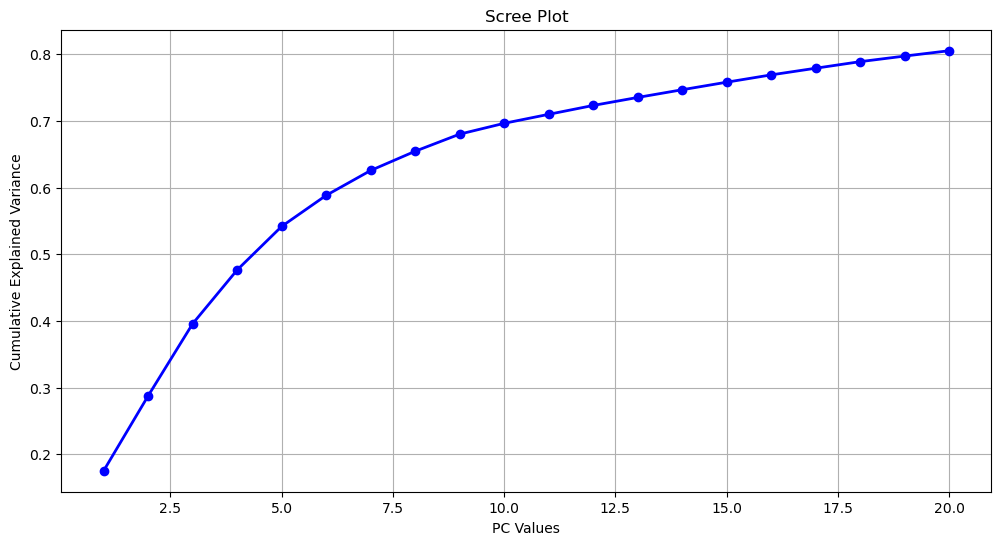

In [4]:
pc_values = np.arange(pca.n_components_)+1
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(12, 6))
plt.plot(pc_values, cumulative_variance, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('PC Values')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

In [5]:
loadings_df = pd.DataFrame(pca.components_).T
loadings_df = loadings_df.set_index(x.columns)
loadings_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
floor_area_sqm,0.404321,0.522842,-0.077402,-0.059992,-0.005766,0.020093,0.056122,0.022841,0.089926,0.039108,0.014704,-0.022075,-0.010596,0.003586,-0.011800,-0.053363,0.028777,-0.013269,-0.016108,0.029102
floor_area_sqft,0.404321,0.522842,-0.077402,-0.059992,-0.005766,0.020093,0.056122,0.022841,0.089926,0.039108,0.014704,-0.022075,-0.010596,0.003586,-0.011800,-0.053363,0.028777,-0.013269,-0.016108,0.029102
price_per_sqft,-0.255323,0.162966,0.362020,-0.459321,0.142158,-0.212833,0.436720,0.047370,-0.172642,0.415056,0.024374,-0.107308,0.063058,-0.142784,0.173936,0.111426,-0.058289,0.073894,0.001154,0.045374
latitude,0.446429,-0.351682,0.144245,0.144846,0.199437,0.136566,0.289591,-0.107831,0.061055,0.120752,-0.013636,0.007786,0.037187,-0.066537,0.131544,-0.002000,0.006626,-0.039965,0.041753,0.052982
longitude,-0.101071,0.220770,0.391790,0.533794,0.432797,0.082834,-0.076290,0.149519,-0.110648,-0.004836,0.008170,-0.035180,0.003365,0.002447,-0.041691,0.026022,0.039904,0.035548,-0.015291,0.053907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
closest_pri_school_YUHUA PRIMARY SCHOOL,0.000111,-0.000573,-0.008500,-0.008158,-0.007249,-0.002758,0.000466,-0.003465,-0.001599,0.004328,0.009972,-0.021354,-0.012207,0.016512,-0.024397,0.013007,-0.013339,0.017792,-0.007269,0.003844
closest_pri_school_YUMIN PRIMARY SCHOOL,-0.000789,0.000813,0.000664,0.004767,0.000507,-0.000912,-0.001620,0.012533,-0.005937,-0.000881,0.001173,-0.005769,-0.002615,0.002927,0.010397,0.000230,0.003239,0.005939,-0.009561,-0.013547
closest_pri_school_ZHANGDE PRIMARY SCHOOL,-0.011739,0.008599,0.003960,-0.009853,-0.007201,-0.011874,0.007742,-0.000567,0.002791,-0.024336,-0.006094,0.020817,0.010165,-0.017822,-0.006595,-0.025136,0.005078,-0.027658,-0.024869,0.001250
closest_pri_school_ZHENGHUA PRIMARY SCHOOL,0.002144,-0.001050,0.000590,-0.002578,-0.010368,0.003430,-0.004791,0.000147,0.004014,-0.000782,0.002379,-0.024358,0.010435,-0.013347,0.018804,0.002868,0.004550,-0.020509,0.020469,-0.002302


In [6]:
loadings_df.where(abs(loadings_df) >= 0.35)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
floor_area_sqm,0.404321,0.522842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area_sqft,0.404321,0.522842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price_per_sqft,NaN,NaN,0.36202,-0.459321,NaN,NaN,0.43672,NaN,NaN,0.415056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,0.446429,-0.351682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
longitude,NaN,NaN,0.39179,0.533794,0.432797,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
closest_pri_school_YUHUA PRIMARY SCHOOL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
closest_pri_school_YUMIN PRIMARY SCHOOL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
closest_pri_school_ZHANGDE PRIMARY SCHOOL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
closest_pri_school_ZHENGHUA PRIMARY SCHOOL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


```
Clustering Features

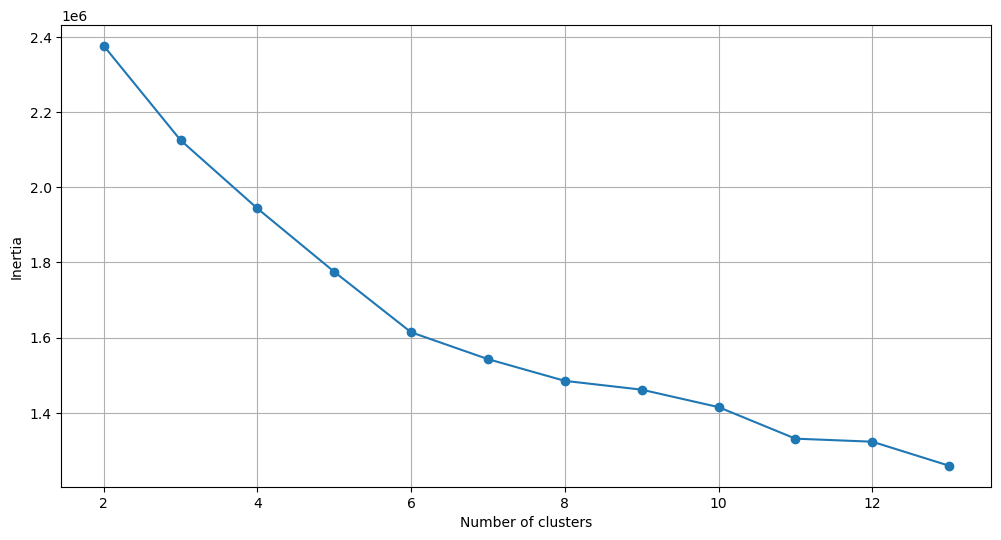

In [7]:
distance_values = []
for cluster in range(2, 14):
    kmeans = KMeans(n_clusters = cluster, init = 'k-means++')
    kmeans.fit(x_pca)
    distance_values.append(kmeans.inertia_)

cluster_output = pd.DataFrame({'Cluster': range(2, 14), 'distance_values': distance_values})

plt.figure(figsize=(12, 6))
plt.plot(cluster_output['Cluster'], cluster_output['distance_values'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid()
plt.show()

In [8]:
kmeans = KMeans(n_clusters = 7, init = 'k-means++', random_state=1)
label = kmeans.fit_predict(x_pca)
x_temp = x.copy()
x_temp['clusters'] = label
x_temp['clusters'].value_counts()

clusters
0    38762
5    35188
1    34947
2    34621
4    25867
6    24662
3    18654
Name: count, dtype: int64

In [12]:
load_df = pd.read_csv('C:/Users/Admin/Downloads/csv_file_transformed.csv')
df = pd.concat([x_temp, load_df['resale_price']], axis=1)
overall_mean = df.apply(np.mean).T
overall_mean = pd.DataFrame(overall_mean, columns=['overall_average'])
overall_mean

,overall_average
floor_area_sqm,-1.028896e-16
floor_area_sqft,-4.572573e-16
price_per_sqft,3.506263e-16
latitude,7.299013e-15
longitude,2.949879e-13
...,...
closest_pri_school_ZHANGDE PRIMARY SCHOOL,1.153732e-02
closest_pri_school_ZHENGHUA PRIMARY SCHOOL,6.845290e-03
closest_pri_school_ZHONGHUA PRIMARY SCHOOL,3.450854e-03
clusters,2.762239e+00


In [11]:
cluster_mean = df.groupby('clusters').mean().T
cluster_mean

clusters,0,1,2,3,4,5,6
floor_area_sqm,0.305142,-0.006175,-0.004605,-0.201015,-0.123691,-1.181378,1.502996
floor_area_sqft,0.305142,-0.006175,-0.004605,-0.201015,-0.123691,-1.181378,1.502996
price_per_sqft,-0.428474,0.083557,-0.411694,2.125966,-0.134966,-0.180548,-0.075897
latitude,-0.137141,0.629407,1.571140,-1.288654,-0.323001,-0.883646,-0.307644
longitude,-1.469226,0.784039,-0.351501,-0.087918,1.014947,0.005127,0.686304
...,...,...,...,...,...,...,...
closest_pri_school_YUMIN PRIMARY SCHOOL,0.000000,0.000000,0.000000,0.000000,0.027023,0.000028,0.004014
closest_pri_school_ZHANGDE PRIMARY SCHOOL,0.000000,0.000000,0.000000,0.094028,0.000116,0.019012,0.001135
closest_pri_school_ZHENGHUA PRIMARY SCHOOL,0.036144,0.000172,0.000000,0.000000,0.000000,0.000313,0.001541
closest_pri_school_ZHONGHUA PRIMARY SCHOOL,0.000000,0.000000,0.000000,0.000965,0.013144,0.006735,0.005636


In [14]:
pd.concat([cluster_mean, overall_mean], axis=1)

,0,1,2,3,4,5,6,overall_average
floor_area_sqm,0.305142,-0.006175,-0.004605,-0.201015,-0.123691,-1.181378,1.502996,-1.028896e-16
floor_area_sqft,0.305142,-0.006175,-0.004605,-0.201015,-0.123691,-1.181378,1.502996,-4.572573e-16
price_per_sqft,-0.428474,0.083557,-0.411694,2.125966,-0.134966,-0.180548,-0.075897,3.506263e-16
latitude,-0.137141,0.629407,1.571140,-1.288654,-0.323001,-0.883646,-0.307644,7.299013e-15
longitude,-1.469226,0.784039,-0.351501,-0.087918,1.014947,0.005127,0.686304,2.949879e-13
...,...,...,...,...,...,...,...,...
closest_pri_school_ZHANGDE PRIMARY SCHOOL,0.000000,0.000000,0.000000,0.094028,0.000116,0.019012,0.001135,1.153732e-02
closest_pri_school_ZHENGHUA PRIMARY SCHOOL,0.036144,0.000172,0.000000,0.000000,0.000000,0.000313,0.001541,6.845290e-03
closest_pri_school_ZHONGHUA PRIMARY SCHOOL,0.000000,0.000000,0.000000,0.000965,0.013144,0.006735,0.005636,3.450854e-03
resale_price,488666.698233,529756.620808,453245.419861,801053.012468,485176.031455,350978.859232,702298.162210,5.186159e+05


Text(0, 0.5, 'Average Resale Price (SGD)')

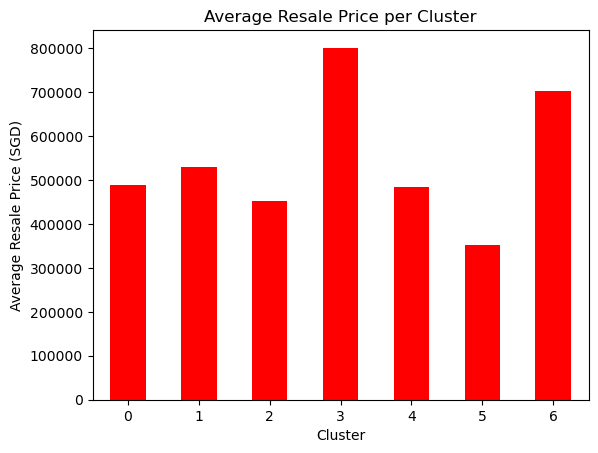

In [17]:
df.groupby('clusters')['resale_price'].mean().plot(kind='bar', color='red')
plt.title('Average Resale Price per Cluster')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.ylabel('Average Resale Price (SGD)')

In [22]:
num_cols = ['floor_area_sqm', 'floor_area_sqft', 'price_per_sqft', 'resale_price']
df.groupby('clusters')[num_cols].mean()

,floor_area_sqm,floor_area_sqft,price_per_sqft,resale_price
clusters,,,,
0,0.305142,0.305142,-0.428474,488666.698233
1,-0.006175,-0.006175,0.083557,529756.620808
2,-0.004605,-0.004605,-0.411694,453245.419861
3,-0.201015,-0.201015,2.125966,801053.012468
4,-0.123691,-0.123691,-0.134966,485176.031455
5,-1.181378,-1.181378,-0.180548,350978.859232
6,1.502996,1.502996,-0.075897,702298.162210


```
Highest resale price: Cluster 3 → 801,053 → most expensive flats

Second highest: Cluster 6 → 702,298 → high-value flats

Lowest: Cluster 5 → 350,979 → cheapest flats

So we can rank clusters by total resale price: 3 > 6 > 1 > 0 > 4 > 2 > 5

Interesting: Cluster 3 has the highest price but slightly below-average size → small but premium location/value.

Even though Cluster 6 has the largest flats, the price per sqft is slightly below average, making them “budget-friendly large units.”

Key Takeaways
Premium flats: Cluster 3 → high price, high price/sqft, slightly smaller

Budget-friendly large flats: Cluster 6 → large flats, lower price per sqft

Affordable flats: Cluster 5 → very small, cheapest resale price

Average flats: Clusters 0,1,2,4 → moderate size and price

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [108]:
df = pd.read_csv('C:/Users/Admin/Downloads/csv_file_transformed.csv')
df['total_remaining_lease_years'] = df['remaining_lease_years'] + df['remaining_lease_months'] / 12
df.head()

,month,town,resale_price,storey_range,flat_type,flat_model,lease_commence_date,remaining_lease_years,remaining_lease_months,floor_area_sqm,...,latitude,longitude,closest_mrt_station,distance_to_mrt_meters,transport_type,line_color,distance_to_cbd,closest_pri_school,distance_to_pri_school_meters,total_remaining_lease_years
0,2017-01-01,ANG MO KIO,232000.0,10 TO 12,2 ROOM,Improved,1979-05-01,61,4,44.0,...,1.362005,103.853880,Ang Mo Kio,999.941618,MRT,Red,8615.656983,TOWNSVILLE PRIMARY SCHOOL,218.125254,61.333333
1,2017-01-01,ANG MO KIO,250000.0,01 TO 03,3 ROOM,New Generation,1978-08-01,60,7,67.0,...,1.370966,103.838202,Ang Mo Kio,1268.958246,MRT,Red,9715.131951,ANG MO KIO PRIMARY SCHOOL,241.572335,60.583333
2,2017-01-01,ANG MO KIO,262000.0,01 TO 03,3 ROOM,New Generation,1980-06-01,62,5,67.0,...,1.380709,103.835368,Yio Chu Kang,1072.295164,MRT,Red,10828.819556,ANDERSON PRIMARY SCHOOL,777.155378,62.416667
3,2017-01-01,ANG MO KIO,265000.0,04 TO 06,3 ROOM,New Generation,1980-02-01,62,1,68.0,...,1.366201,103.857201,Ang Mo Kio,945.371842,MRT,Red,9097.929095,TECK GHEE PRIMARY SCHOOL,698.165530,62.083333
4,2017-01-01,ANG MO KIO,265000.0,01 TO 03,3 ROOM,New Generation,1980-06-01,62,5,67.0,...,1.381041,103.835132,Yio Chu Kang,1095.197729,MRT,Red,10869.453109,ANDERSON PRIMARY SCHOOL,782.553222,62.416667


In [109]:
monthly_prices = df.groupby('month')['resale_price'].mean()

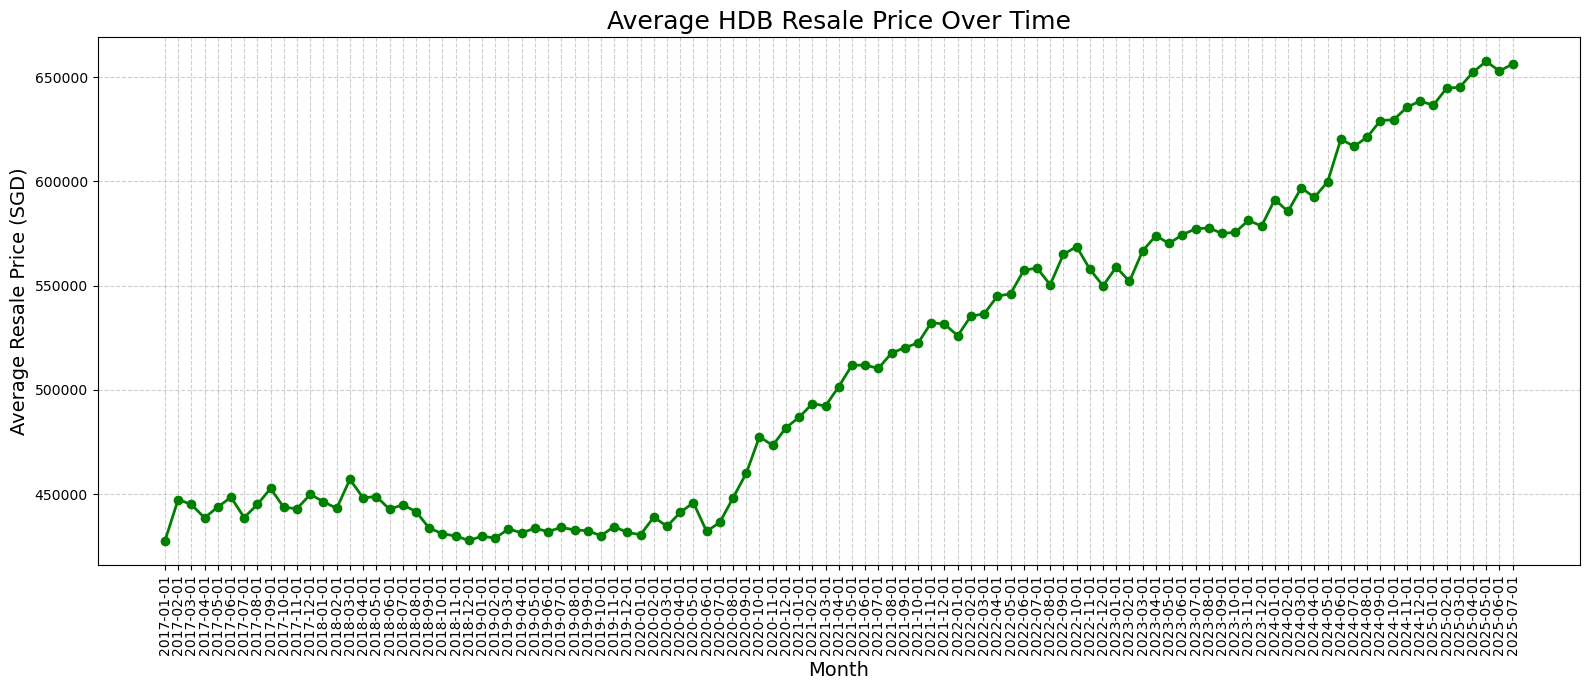

In [110]:
plt.figure(figsize=(16, 7))
plt.plot(monthly_prices.index, monthly_prices.values, color='green', linewidth=2, marker='o')

plt.title("Average HDB Resale Price Over Time", fontsize=18)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Average Resale Price (SGD)", fontsize=14)

plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

```
2017 – 2019: Flat / Slight Decline

Prices hover between $430k – $450k.

Some months even show mild decline.

This matches the effect of cooling measures (2013–2019) when resale prices stagnated.

2020 – 2021: Strong Upturn

Around early 2020, prices sharply rise.

Likely linked to COVID-19 disruptions (construction delays, supply shortages, higher demand for resale flats).

2021 – 2023: Accelerated Growth

Prices continue to climb steeply from ~$480k → ~$600k+.

This period reflects record high resale demand (confirmed by HDB statistics).

2023 – 2025: Continued Uptrend

Prices stabilize briefly but keep increasing.

By mid-2025, average prices exceed $650k.

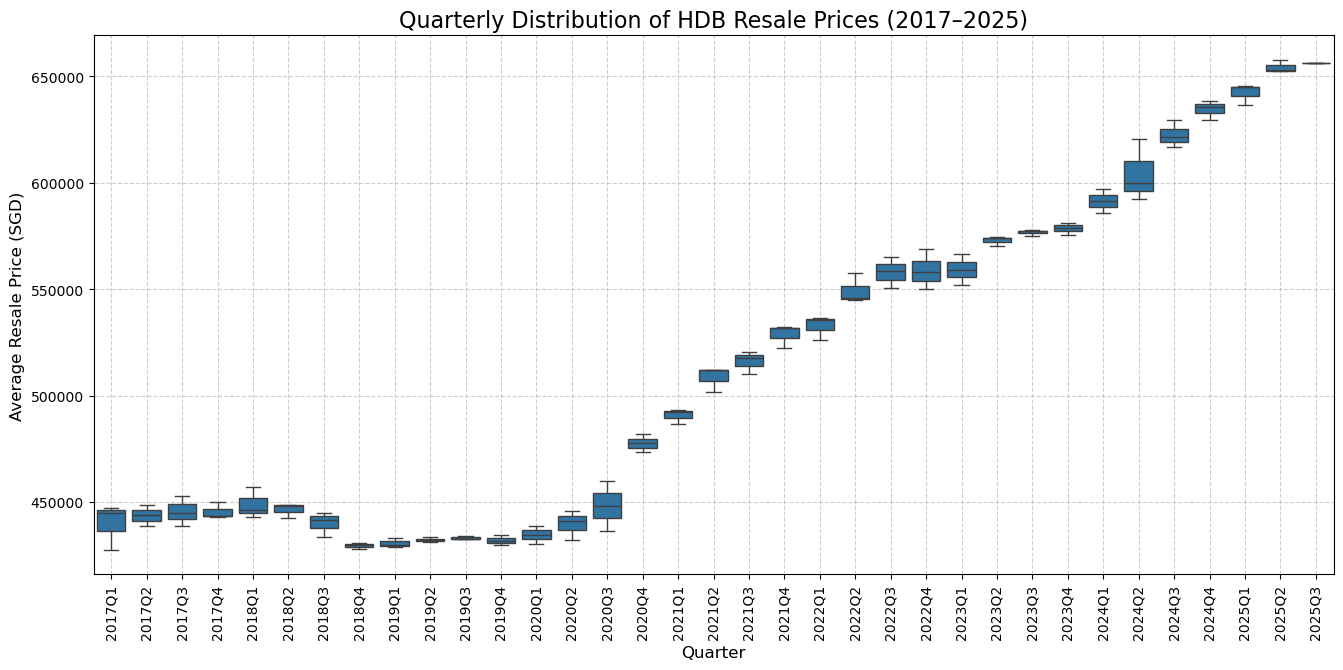

In [111]:
monthly_prices_df = pd.DataFrame(monthly_prices.values, monthly_prices.index, columns=['resale_price'])
monthly_prices_df
plt.figure(figsize=(16, 7))
ax = sns.boxplot(data=monthly_prices_df, x=pd.PeriodIndex(monthly_prices.index, freq='Q').astype(str), y='resale_price')
plt.xticks(rotation=90)
plt.title("Quarterly Distribution of HDB Resale Prices (2017–2025)", fontsize=16)
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Average Resale Price (SGD)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

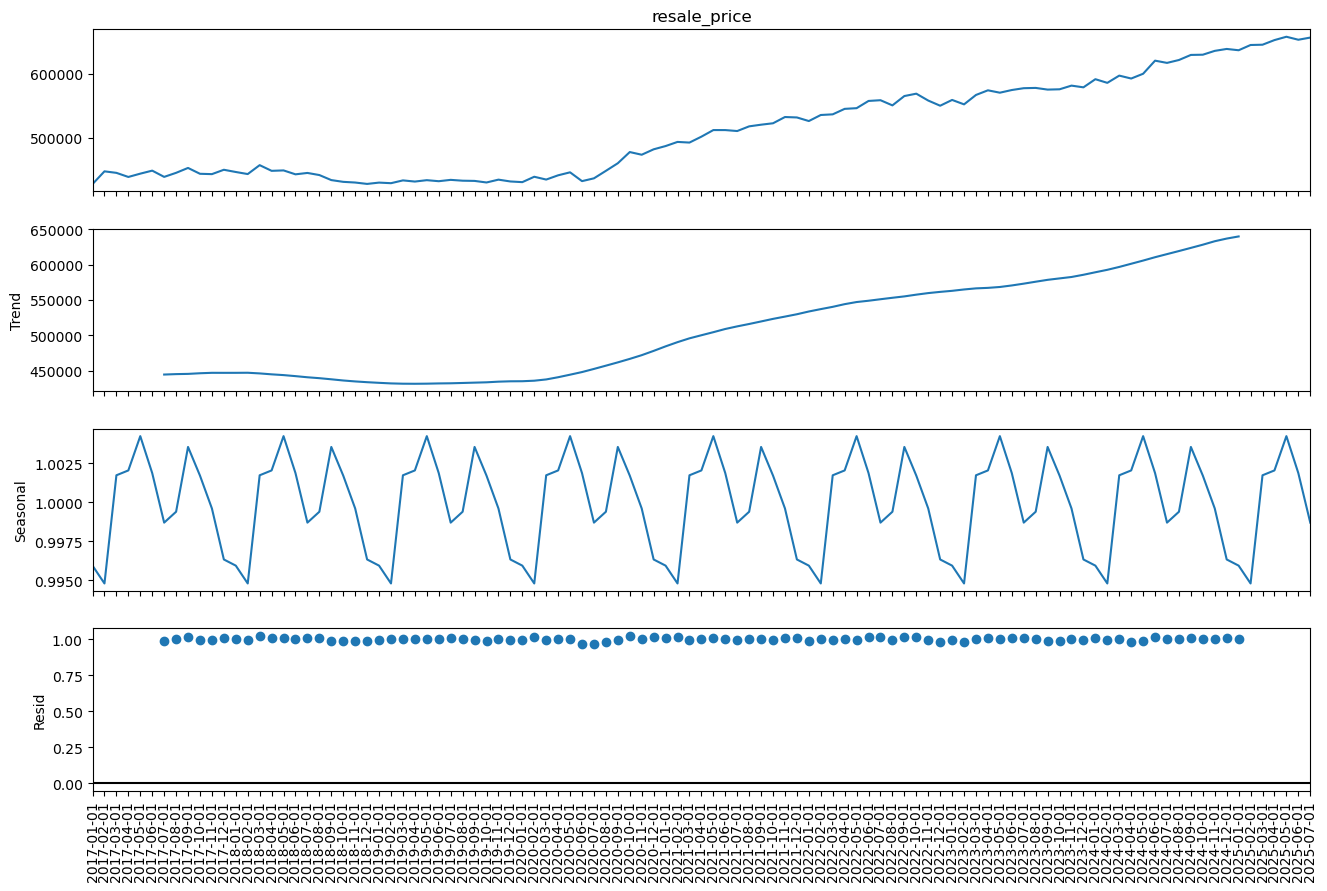

In [112]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_multi = seasonal_decompose(monthly_prices_df['resale_price'], model='multiplicative', period=12)
fig = decomposition_multi.plot()
fig.set_size_inches((16, 9))
plt.xticks(rotation=90)
plt.show()

```
Trend Component

The resale prices show a long-term upward trend.

From 2017 to around 2019, prices stayed fairly flat.

Starting in 2020, resale prices increased steadily and strongly, reflecting Singapore’s housing market changes post-COVID and demand surge.

Seasonal Component

There is a repeated yearly pattern in the data.

Seasonal effects are small (±0.3%) but consistent.

This means certain months tend to have slightly higher or lower prices compared to the overall yearly average.

Because the model is multiplicative, these seasonal fluctuations scale with the price level.

Example: when prices are $450k, a +0.3% seasonal effect = +$1.3k.

When prices rise to $650k, the same seasonal effect = +$1.95k.

Residual Component

After removing the trend + seasonality, the residuals are mostly random noise.

No strong patterns remain, meaning the decomposition explains the data well.

Occasional spikes suggest short-term shocks, possibly due to policy changes, unusual demand, or macroeconomic events.

In [113]:
moving_data = monthly_prices_df.rolling(window=4)
moving_average_data = moving_data.mean()
moving_average_data

,resale_price
month,
2017-01-01,NaN
2017-02-01,NaN
2017-03-01,NaN
2017-04-01,439641.222137
2017-05-01,443711.806238
...,...
2025-03-01,641289.934019
2025-04-01,644748.296965
2025-05-01,650020.383064


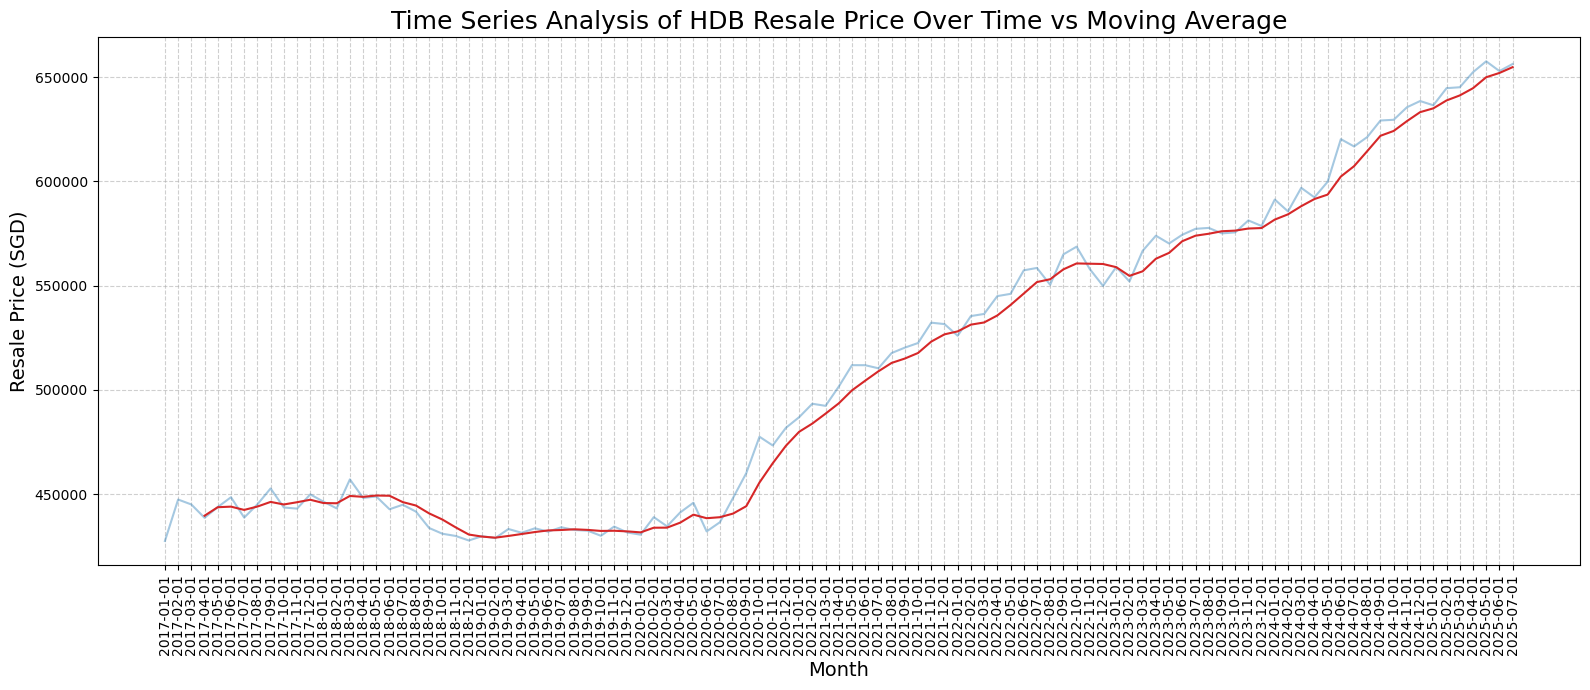

In [114]:
plt.figure(figsize=(16, 7))
plt.plot(monthly_prices_df.index, monthly_prices_df['resale_price'], color='tab:blue', alpha=0.4)
plt.plot(moving_average_data.index, moving_average_data['resale_price'], color='tab:red')
plt.title('Time Series Analysis of HDB Resale Price Over Time vs Moving Average', fontsize=18)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Resale Price (SGD)', fontsize=14)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

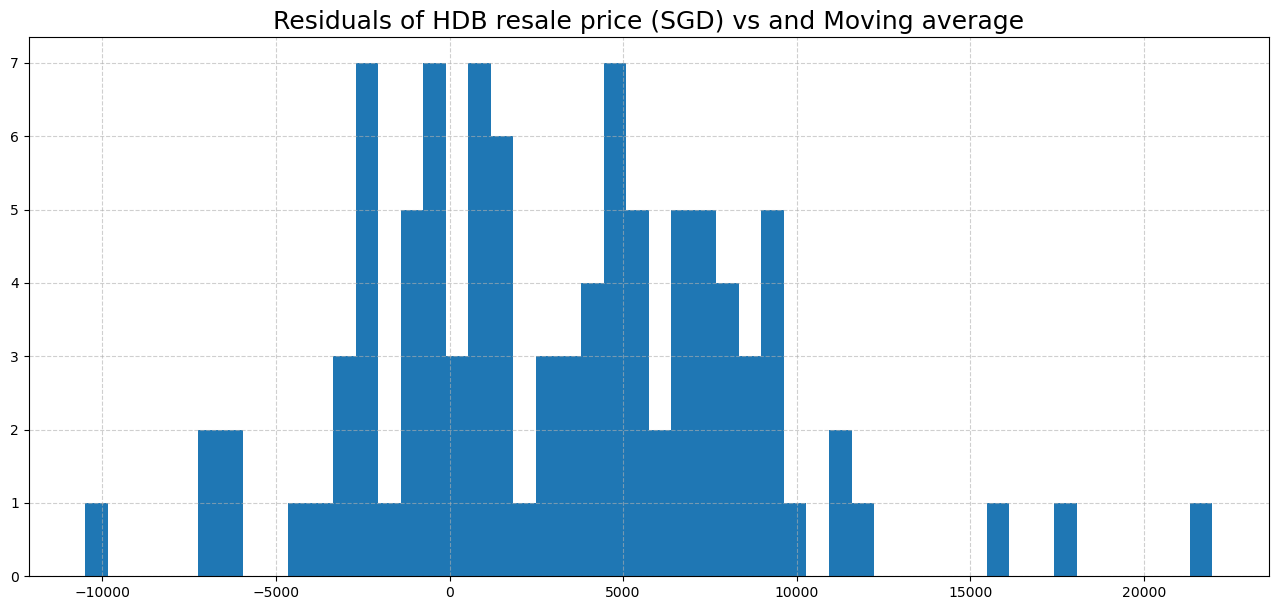

In [115]:
plt.figure(figsize=(16, 7))
residuals = monthly_prices_df - moving_average_data
plt.hist(residuals, bins=50)
plt.title('Residuals of HDB resale price (SGD) vs and Moving average', fontsize=18)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

```
The histogram of residuals between actual HDB resale prices and their moving average shows that most residuals are concentrated around zero, indicating that the moving average captures the general price trend effectively. However, the distribution is right-skewed, with a few large positive residuals, suggesting occasional months where actual resale prices significantly exceed the moving average. Negative residuals are fewer and smaller in magnitude, and the presence of extreme positive values highlights potential outliers or spikes in the market

```
Examine the residuals with very high values.

In [116]:
percentile_90 = np.nanpercentile(abs(residuals['resale_price']), 90)
residuals[abs(residuals['resale_price']) >= percentile_90]

,resale_price
month,
2020-09-01,15858.461030
2020-10-01,21965.536079
2021-02-01,9501.596190
2021-05-01,12079.243194
2022-06-01,11144.990531
2022-12-01,-10500.966421
2023-03-01,9821.745274
2023-04-01,11055.825854
2024-01-01,9627.988407


In [117]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
exponential_model = ExponentialSmoothing(monthly_prices_df)
fit = exponential_model.fit(smoothing_level=0.8)
fitted_values = fit.fittedvalues

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


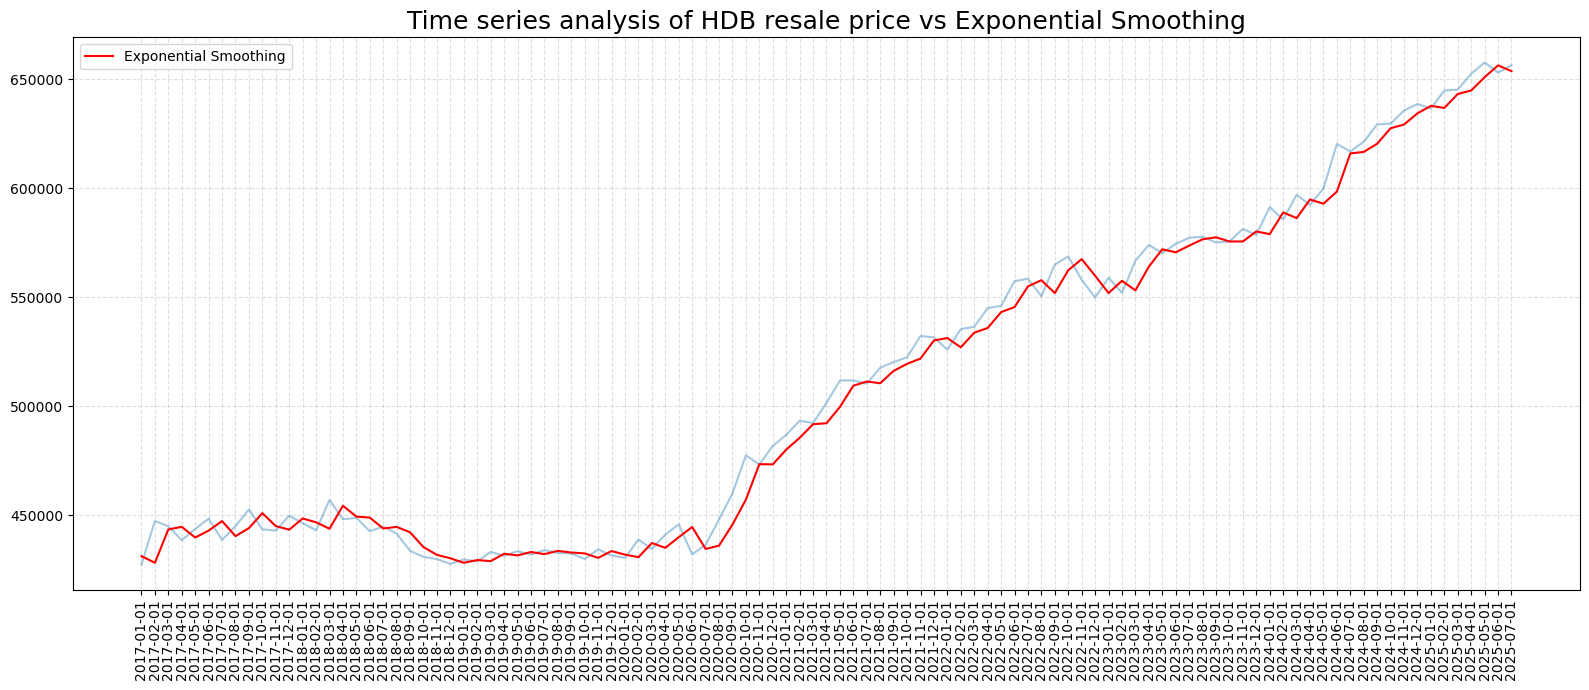

In [118]:
plt.figure(figsize=(16, 7))
plt.plot(monthly_prices_df.index, monthly_prices_df['resale_price'], color='tab:blue', alpha=0.4)
plt.plot(fitted_values.index, fitted_values.values, label='Exponential Smoothing', color='red')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.title('Time series analysis of HDB resale price vs Exponential Smoothing', fontsize=18)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

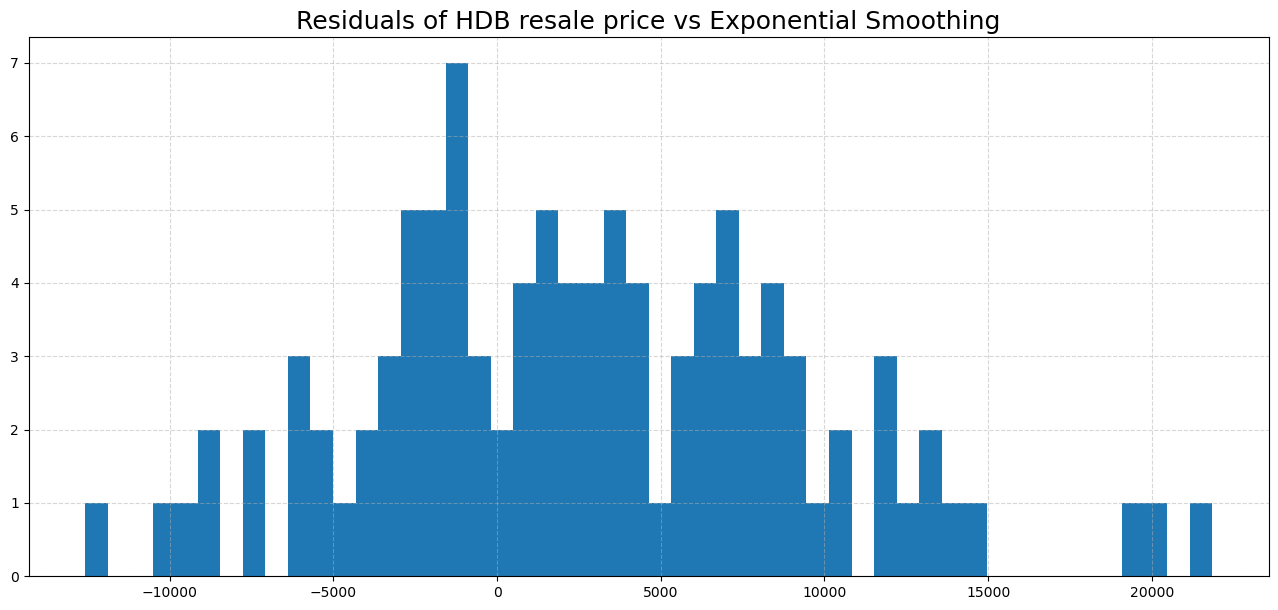

In [119]:
plt.figure(figsize=(16, 7))
residuals = monthly_prices_df.squeeze() - fitted_values
plt.hist(residuals, bins=50)
plt.title('Residuals of HDB resale price vs Exponential Smoothing', fontsize=18)
plt.grid(True, alpha=0.5, linestyle='--')
plt.show()

In [120]:
residuals = pd.DataFrame(residuals.values, index=residuals.index, columns=['resale_price'])
percentile_90 = np.nanpercentile(abs(residuals['resale_price']), 90)
residuals[abs(residuals['resale_price']) >= percentile_90]

,resale_price
month,
2017-02-01,19131.858245
2018-03-01,13187.727544
2020-06-01,-12588.546571
2020-08-01,12068.688986
2020-09-01,14299.855100
2020-10-01,20324.867364
2021-05-01,12153.950472
2022-09-01,13107.713433
2023-03-01,13591.286776


In [121]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
adf_result = adfuller(monthly_prices_df, autolag='AIC')
print('ADF Test Statistic: ', adf_result[0], '\n')
print('p value: ', adf_result[1], '\n')
print('Critical Values: ', adf_result[4], '\n')
if adf_result[0] < adf_result[4]['5%']:
    print('Reject Null hypothesis - Time Series is Stationary')
else:
    print('Failed to Reject Null hypothesis - Time Series is Non-Stationary')

ADF Test Statistic:  1.6880535610780953 

p value:  0.9980991044613039 

Critical Values:  {'1%': np.float64(-3.4968181663902103), '5%': np.float64(-2.8906107514600103), '10%': np.float64(-2.5822770483285953)} 

Failed to Reject Null hypothesis - Time Series is Non-Stationary


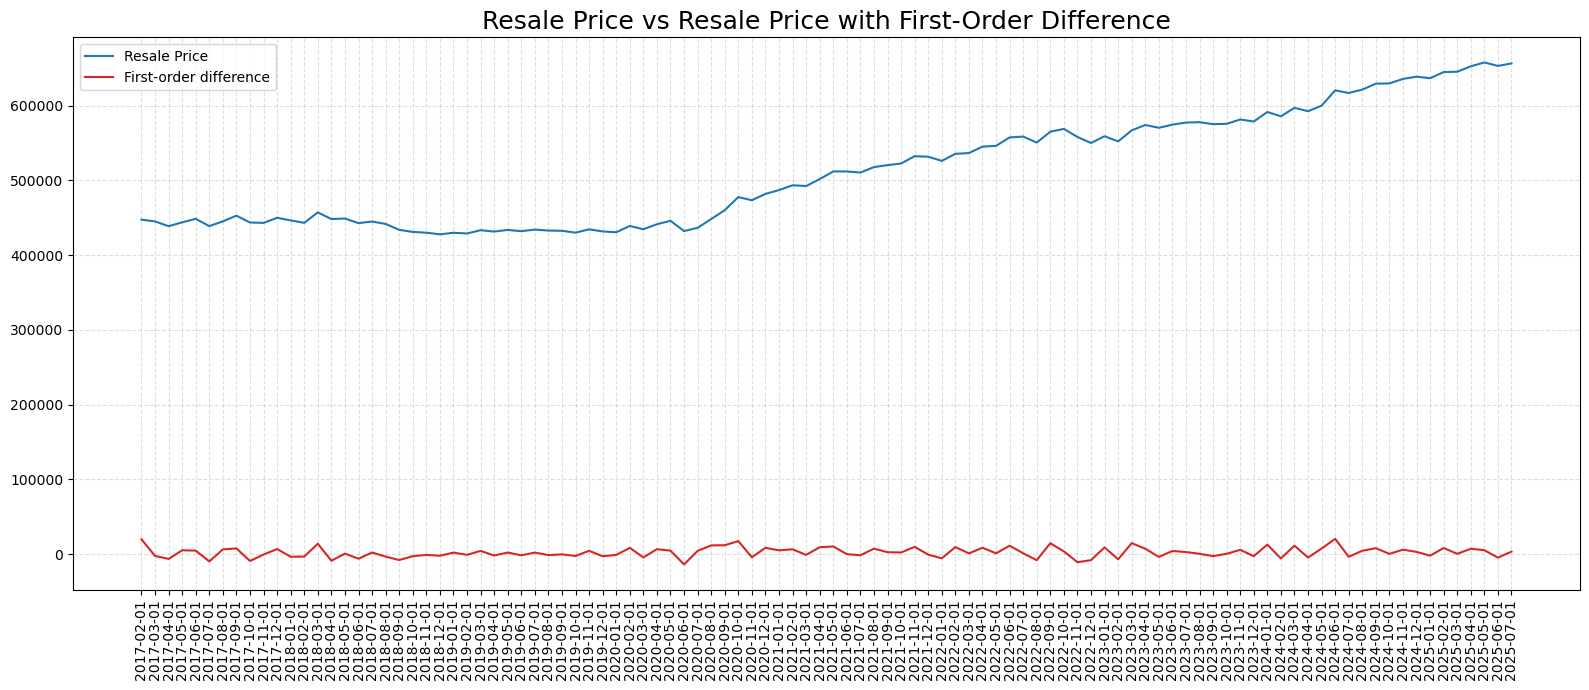

In [122]:
monthly_prices_df = monthly_prices_df.copy()
monthly_prices_df['Difference'] = monthly_prices_df['resale_price'].diff(periods=1)
monthly_prices_df = monthly_prices_df.dropna()
monthly_prices_df.head()

plt.figure(figsize=(16, 7))
plt.plot(monthly_prices_df['resale_price'], label='Resale Price')
plt.plot(monthly_prices_df['Difference'], label='First-order difference', color='tab:red')
plt.legend()
plt.title('Resale Price vs Resale Price with First-Order Difference', fontsize=18)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

```
The original resale price series shows a clear upward trend, indicating non-stationarity. After applying first-order differencing, the resulting series fluctuates around zero with no consistent trend, suggesting that differencing has successfully removed the trend component and made the series more stationary. This transformation is important for time series models like ARIMA that assume stationarity.

In [123]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(monthly_prices_df['Difference'], autolag='AIC')
print('ADF Test Statistic: ', adf_result[0], '\n')
print('p value: ', adf_result[1], '\n')
print('Critical Values: ', adf_result[4], '\n')
if adf_result[0] < adf_result[4]['5%']:
    print('Reject Null hypothesis - Time Series is Stationary')
else:
    print('Failed to Reject Null hypothesis - Time Series is Non-Stationary')

ADF Test Statistic:  -12.498516691631222 

p value:  2.840608431934054e-23 

Critical Values:  {'1%': np.float64(-3.4968181663902103), '5%': np.float64(-2.8906107514600103), '10%': np.float64(-2.5822770483285953)} 

Reject Null hypothesis - Time Series is Stationary


In [127]:
from statsmodels.tsa.stattools import acf, pacf
acf_values = acf(monthly_prices_df['resale_price'], nlags=24)
for i in range(0, 25):
    print('lag ', i, ' ', np.round(acf_values[i], 2))

lag  0   1.0
lag  1   0.97
lag  2   0.95
lag  3   0.92
lag  4   0.89
lag  5   0.87
lag  6   0.84
lag  7   0.81
lag  8   0.78
lag  9   0.75
lag  10   0.72
lag  11   0.69
lag  12   0.66
lag  13   0.63
lag  14   0.6
lag  15   0.58
lag  16   0.55
lag  17   0.53
lag  18   0.5
lag  19   0.47
lag  20   0.45
lag  21   0.42
lag  22   0.39
lag  23   0.36
lag  24   0.33


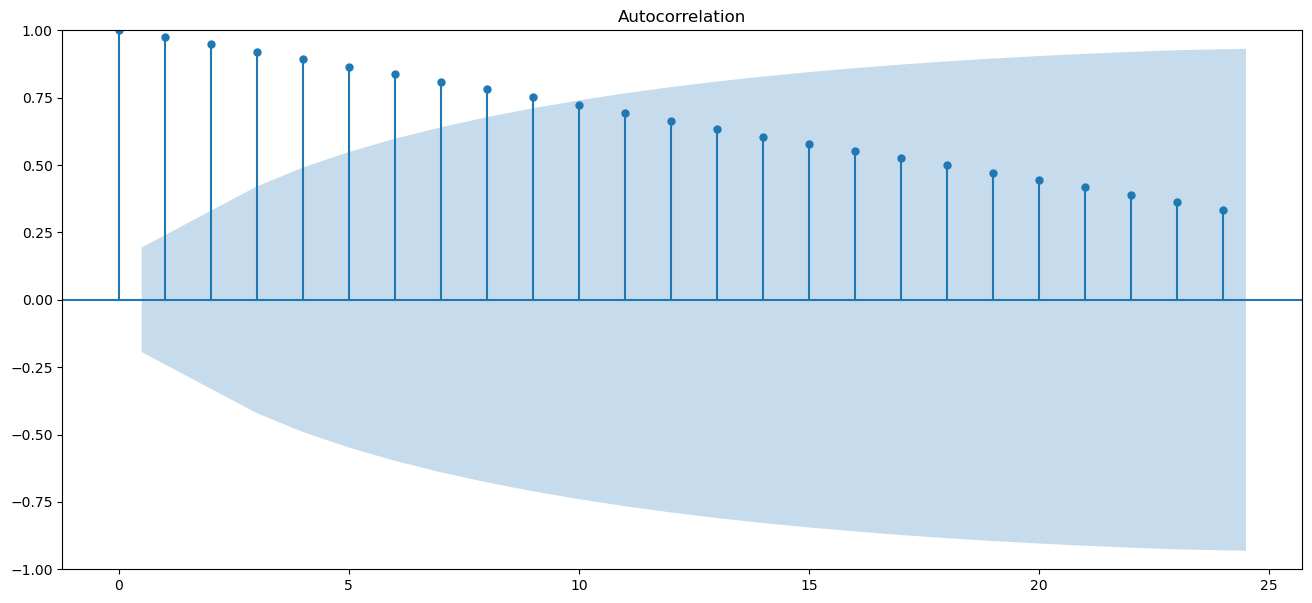

In [136]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig = plot_acf(monthly_prices_df['resale_price'], lags=24)
fig.set_size_inches((16, 7))

```
The autocorrelation function (ACF) shows very high positive correlations that decay slowly across many lags, with most values lying well outside the confidence bands. This indicates that the series is strongly persistent and non-stationary, most likely due to an underlying upward trend in the data. Such a pattern suggests the need for differencing to achieve stationarity before applying ARIMA or other time series forecasting models.



In [137]:
pacf_values = pacf(monthly_prices_df['resale_price'], method='ols', nlags=24)
for i in range(0, 25):
    print('lag ', i, ' ', np.round(acf_values[i], 2))

lag  0   1.0
lag  1   0.97
lag  2   0.95
lag  3   0.92
lag  4   0.89
lag  5   0.87
lag  6   0.84
lag  7   0.81
lag  8   0.78
lag  9   0.75
lag  10   0.72
lag  11   0.69
lag  12   0.66
lag  13   0.63
lag  14   0.6
lag  15   0.58
lag  16   0.55
lag  17   0.53
lag  18   0.5
lag  19   0.47
lag  20   0.45
lag  21   0.42
lag  22   0.39
lag  23   0.36
lag  24   0.33


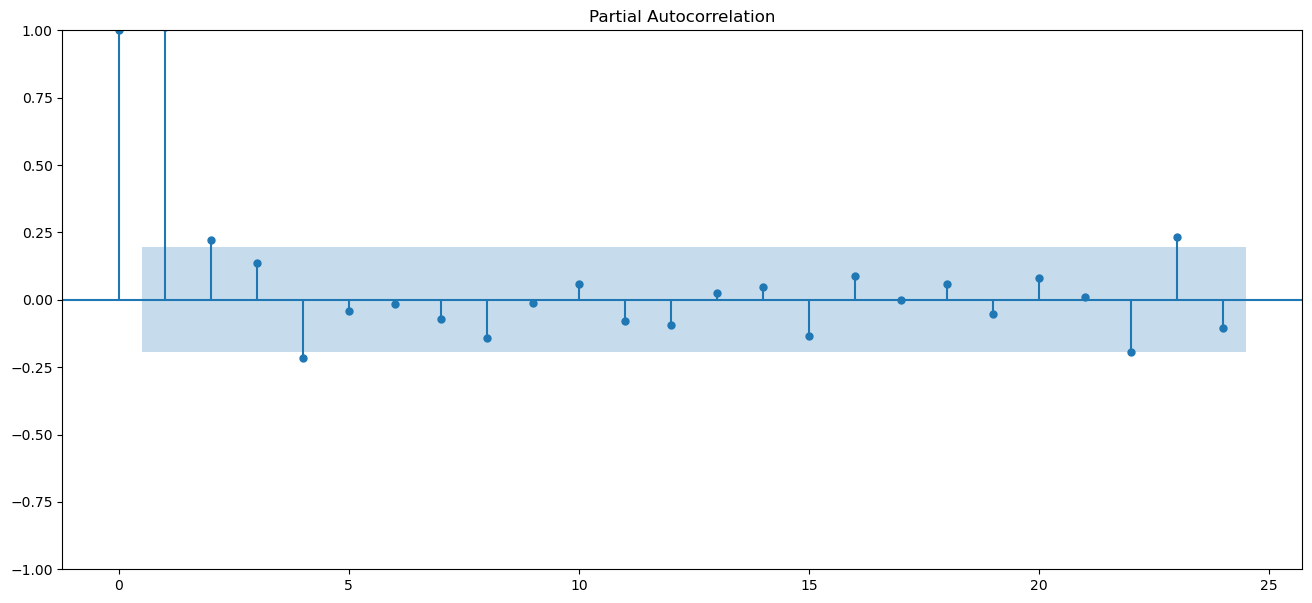

In [138]:
fig = plot_pacf(monthly_prices_df['resale_price'], method='ols', lags=24)
fig.set_size_inches((16, 7))

```
The PACF plot for HDB resale prices shows strong dependence on the last two months, a weaker but still significant effect at three months, and mostly no direct impact beyond that. Interestingly, there are small spikes at 21–22 months, suggesting a faint two-year cycle in the housing market. This means resale prices are primarily driven by short-term movements, but with occasional longer-term influences